In [55]:
import lightning as L
import timm
import torch
from pytorch_metric_learning import miners
import torchvision.transforms as T
import cv2
from torch.utils.data import DataLoader
import os
import random
import lightning.pytorch as pl
from lightning.pytorch.callbacks import ModelCheckpoint
from lightning.pytorch.callbacks.early_stopping import EarlyStopping
from lightning.pytorch.callbacks import LearningRateMonitor
import torchmetrics
import matplotlib.pyplot as plt
import numpy as np
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image
torch.set_float32_matmul_precision('high')
import pandas as pd

In [46]:
class CarsEmbedder(L.LightningModule):
    def __init__(self, margin=1.0, lr=1e-4, k=5):
        super().__init__()
        self.save_hyperparameters()
        self.model = timm.create_model(model_name='efficientnet_b1', pretrained=True, num_classes=0)

        self.loss = torch.nn.TripletMarginLoss(margin=margin)
        self.miner = miners.TripletMarginMiner(margin=margin, type_of_triplets="semihard")

        self.val_precision = torchmetrics.retrieval.RetrievalPrecision(top_k=k)
        self.val_recall = torchmetrics.retrieval.RetrievalRecall(top_k=k)
        self.val_map = torchmetrics.retrieval.RetrievalMAP()
        self.validation_step_outputs = []
        self.validation_step_labels = []

    def forward(self, imgs):
        return self.model(imgs)

    def training_step(self, batch):
        imgs, labels = batch

        embeds = self(imgs)

        anchors_indices, positives_indices, negatives_indices = self.miner(embeds, labels)
        loss = self.loss(embeds[anchors_indices], embeds[positives_indices], embeds[negatives_indices])
        self.log('train_loss', loss)
        return loss

    @staticmethod
    def precision_k_for_one(main_embed, main_label, other_embeds, labels, k=5, distances_sorted=None):
        res = 0
        nearest = []
        if distances_sorted is None:
            distances = torch.nn.functional.cosine_similarity(main_embed.unsqueeze(0), other_embeds)
            distances = list(enumerate(distances.detach().cpu()))
            nearest = sorted(distances, key=lambda x: x[1], reverse=True)[1:k+1]
        else:
            nearest = distances_sorted[1:k+1]
        res += sum(1 for idx, dist in nearest if labels[idx] == main_label) / k
        return res

    @staticmethod
    def recall_k(embeds, labels, k=5):
        res = 0
        for i, embed in enumerate(embeds):
            main_label = labels[i]
            main_label_count = max(1, sum(1 for label in labels if label == main_label) - 1)
            distances = torch.nn.functional.cosine_similarity(embed.unsqueeze(0), embeds)
            distances = list(enumerate(distances.detach().cpu()))
            nearest = sorted(distances, key=lambda x: x[1], reverse=True)[1:k+1]
            res += sum(1 for idx, dist in nearest if labels[idx] == main_label) / main_label_count
        return res / len(embeds)

    @staticmethod
    def m_ap(embeds, labels):
        res = 0
        for i, embed in enumerate(embeds):
            main_label = labels[i]
            distances = torch.nn.functional.cosine_similarity(embed.unsqueeze(0), embeds)
            distances = list(enumerate(distances.detach().cpu()))
            ranked = sorted(distances, key=lambda x: x[1], reverse=True)[1:]

            relevants_count = max(1, sum(1 for label in labels if label == main_label) - 1)
            res += sum(CarsEmbedder.precision_k_for_one(embed, main_label, embeds, labels, k, distances_sorted=ranked) for k in range(1, len(ranked)+1) if labels[ranked[k-1][0]] == main_label) / relevants_count
        return res / len(embeds)

    def metrics_with_pytorch(self, embeds, labels):
            embeds_normalized = torch.nn.functional.normalize(embeds, p=2, dim=1)
            similarity_matrix = torch.matmul(embeds_normalized, embeds_normalized.T)
            num_samples = len(labels)
            query_indices = torch.arange(num_samples, device=self.device).repeat_interleave(num_samples)

            mask = torch.ones_like(similarity_matrix, dtype=torch.bool, device=self.device)
            mask.fill_diagonal_(False)

            query_indices = query_indices[mask.flatten()]
            preds = similarity_matrix[mask]

            target_labels = (labels.unsqueeze(1) == labels.unsqueeze(0))[mask]

            self.val_precision.update(preds, target_labels, indexes=query_indices)
            self.val_recall.update(preds, target_labels, indexes=query_indices)
            self.val_map.update(preds, target_labels, indexes=query_indices)

            self.log("val_precision@k_torchmetrics", self.val_precision.compute(), prog_bar=True)
            self.log("val_recall@k_torchmetrics", self.val_recall.compute(), prog_bar=True)
            self.log("val_mAP_torchmetrics", self.val_map.compute(), prog_bar=True)

    def validation_step(self, batch):
        imgs, labels = batch

        embeds = self(imgs)

        anchors_indices, positives_indices, negatives_indices = self.miner(embeds, labels)
        loss = self.loss(embeds[anchors_indices], embeds[positives_indices], embeds[negatives_indices])
        self.log("val_loss", loss, on_step=False, on_epoch=True)

        self.validation_step_outputs.append(embeds.detach().cpu())
        self.validation_step_labels.append(labels.detach().cpu())

    def on_validation_epoch_end(self):

        embeds = torch.cat(self.validation_step_outputs, dim=0)
        labels = torch.cat(self.validation_step_labels, dim=0)
        embeds_normalized = torch.nn.functional.normalize(embeds)
        prec_k = 0
        for embed, label in zip(embeds_normalized, labels):
            prec_k += self.precision_k_for_one(embed, label, embeds, labels, k=5)
        prec_k /= len(embeds_normalized)
        rec_k = self.recall_k(embeds_normalized, labels)
        m_ap = self.m_ap(embeds_normalized, labels)
        self.log(f"val_precision@k", prec_k)
        self.log(f"val_recall@k", rec_k)
        self.log("val_mAP", m_ap)

        #self.metrics_with_pytorch(embeds, labels)

        self.validation_step_labels.clear()
        self.validation_step_outputs.clear()

    def configure_optimizers(self):
        optimizer = torch.optim.Adam(self.parameters(), lr=self.hparams.lr)
        return optimizer

In [47]:
ADD_PATH = 'cars_train'
BATCH_SIZE = 64

In [48]:
class CarsDataset(torch.utils.data.Dataset):
    def __init__(self, data, transforms=None):
        self.data = data
        if transforms is not None:
            self.transforms = transforms
        else:
            self.transforms = T.Compose([T.ToPILImage(), T.Resize((224, 224)), T.ToTensor(), T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])])

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        filename, cl_id = self.data[idx]
        path = os.path.join(ADD_PATH, filename)
        image = cv2.imread(path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        if self.transforms:
            image = self.transforms(image)
        return image, cl_id

In [49]:
import scipy.io
mat = scipy.io.loadmat('./devkit/cars_train_annos.mat')
fname_to_class = {fname:cl-1 for fname, cl in zip([i[0] for i in mat['annotations'][0]['fname']],
                                                [i[0][0] for i in mat['annotations'][0]['class']])}
cars_meta = scipy.io.loadmat('./devkit/cars_meta.mat')
id_to_car = {idx: car[0] for idx, car in enumerate(cars_meta['class_names'][0])}

In [50]:
items = list(fname_to_class.items())
random.shuffle(items)
train_items = items[:int(len(items) * 0.8)]
val_items = items[int(len(items) * 0.8):]

train_transforms = T.Compose([
    T.ToPILImage(),
    T.Resize((240, 240)),
    T.RandomCrop((224, 224)),
    T.RandomHorizontalFlip(p=0.5),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_dataset = CarsDataset(train_items, train_transforms)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, pin_memory=True)
val_dataset = CarsDataset(val_items)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, pin_memory=True)

In [51]:
pl_model = CarsEmbedder()
checkpoint_callback = ModelCheckpoint(monitor='val_loss',mode='min',  save_top_k=5)
early_stopping = EarlyStopping(monitor="val_loss", mode="min", patience=2)
lr_monitor = LearningRateMonitor(logging_interval='step')

trainer = pl.Trainer(
    max_epochs=15,
    accelerator='cuda',
    callbacks=[checkpoint_callback, early_stopping, lr_monitor],
    precision='16-mixed',
)

Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


In [52]:
trainer.fit(pl_model, train_loader, val_loader)

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name          | Type               | Params | Mode 
-------------------------------------------------------------
0 | model         | EfficientNet       | 6.5 M  | train
1 | loss          | TripletMarginLoss  | 0      | train
2 | miner         | TripletMarginMiner | 0      | train
3 | val_precision | RetrievalPrecision | 0      | train
4 | val_recall    | RetrievalRecall    | 0      | train
5 | val_map       | RetrievalMAP       | 0      | train
-------------------------------------------------------------
6.5 M     Trainable params
0         Non-trainable params
6.5 M     Total params
26.053    Total estimated model params size (MB)
479       Modules in train mode
0         Modules in eval mode


Epoch 0: 100%|██████████| 102/102 [02:32<00:00,  0.67it/s, v_num=28]       
Validation: |          | 0/? [00:00<?, ?it/s]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 1: 100%|██████████| 102/102 [02:41<00:00,  0.63it/s, v_num=28, val_precision@k_torchmetrics=0.0624, val_recall@k_torchmetrics=0.0387, val_mAP_torchmetrics=0.0551]
Validation: |          | 0/? [00:00<?, ?it/s]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 2: 100%|██████████| 102/102 [02:59<00:00,  0.57it/s, v_num=28, val_precision@k_torchmetrics=0.103, val_recall@k_torchmetrics=0.0321, val_mAP_torchmetrics=0.0548] 
Validation: |          | 0/? [00:00<?, ?it/s]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 3: 100%|██████████| 102/102 [02:59<00:00,  0.57it/s, v_num=28, val_precision@k_torchmetrics=0.144, val_recall@k_torchmetrics=0.0302, val_mAP_torchmetrics=0.0613]
Validation: |          | 0/? [00:00<?, ?it/s]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 4: 100%|██████████| 102/102 [03:38<00:00,  0


Detected KeyboardInterrupt, attempting graceful shutdown ...


SystemExit: 1

In [35]:
trainer.save_checkpoint("best_model.ckpt")

In [84]:
best_model_path = trainer.checkpoint_callback.best_model_path
pl_model = CarsEmbedder.load_from_checkpoint("best_model.ckpt")

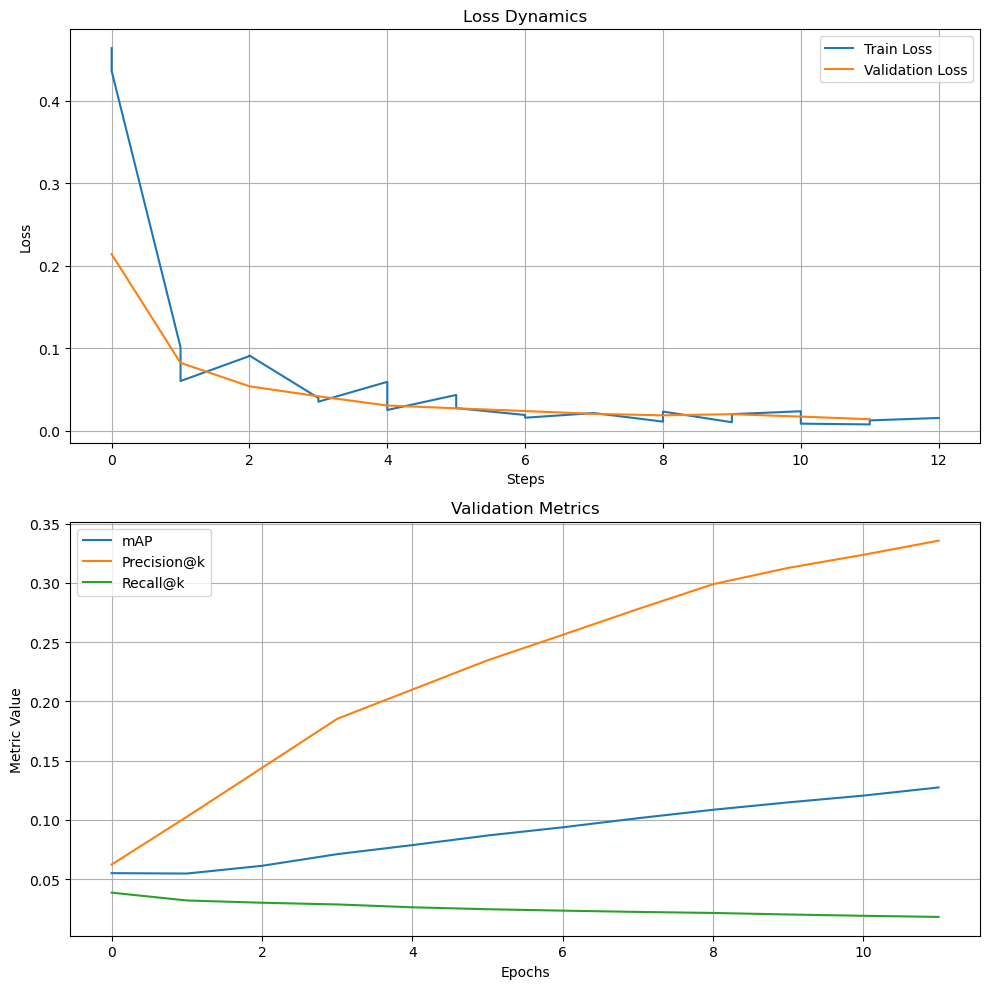

In [60]:
df = pd.read_csv('metrics.csv')
val_data = df.dropna(subset=['val_loss'])
train_data = df.dropna(subset=['train_loss'])

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10))

ax1.plot(train_data['epoch'], train_data['train_loss'], label='Train Loss')
ax1.plot(val_data['epoch'], val_data['val_loss'], label='Validation Loss')
ax1.set_title('Loss Dynamics')
ax1.set_xlabel('Steps')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True)

ax2.plot(val_data['epoch'], val_data['val_mAP_torchmetrics'], label='mAP')
ax2.plot(val_data['epoch'], val_data['val_precision@k_torchmetrics'], label='Precision@k')
ax2.plot(val_data['epoch'], val_data['val_recall@k_torchmetrics'], label='Recall@k')
ax2.set_title('Validation Metrics')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Metric Value')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

In [89]:
def denormalize(tensor):
    mean = torch.tensor([0.485, 0.456, 0.406])
    std = torch.tensor([0.229, 0.224, 0.225])

    tensor = tensor.clone() * std[:, None, None] + mean[:, None, None]
    tensor = torch.clamp(tensor, 0, 1)

    return tensor
class SimilarityToConceptTarget:
    def __init__(self, concept_features):
        self.concept_features = concept_features

    def __call__(self, model_output):
        cos = torch.nn.CosineSimilarity(dim=1)
        return cos(model_output, self.concept_features)

def find_and_show_similar_with_gradcam(model, dataset, query_idx, k=5):
    model.eval()
    device = 'cuda'

    query_img, query_label = dataset[query_idx]
    query_img_tensor = query_img.unsqueeze(0).to(device)

    with torch.no_grad():
        query_embed = model(query_img_tensor)

    all_embeds_gpu = []
    loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False)
    for imgs, _ in loader:
        with torch.no_grad():
            embeds = model(imgs.to(device))
            all_embeds_gpu.append(embeds)
    all_embeds_gpu = torch.cat(all_embeds_gpu)

    similarities = torch.nn.functional.cosine_similarity(query_embed, all_embeds_gpu)
    sorted_indices = torch.argsort(similarities, descending=True)
    top_k_indices = sorted_indices.cpu().numpy()[1:k+1]

    target_layer = [model.model.conv_head]

    cam_targets = [SimilarityToConceptTarget(query_embed)]

    fig, axes = plt.subplots(2, k + 1, figsize=(15, 7))
    all_indices = [query_idx] + list(top_k_indices)

    with GradCAM(model=model, target_layers=target_layer) as cam:
        for i, idx in enumerate(all_indices):
            img, label = dataset[idx]
            input_tensor = img.unsqueeze(0).to(device)

            grayscale_cam = cam(input_tensor=input_tensor, targets=cam_targets)[0, :]

            rgb_img = denormalize(img).permute(1, 2, 0).numpy()
            visualization = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

            axes[0, i].imshow(rgb_img)
            axes[0, i].axis('off')

            axes[1, i].imshow(visualization)
            axes[1, i].axis('off')

            if i == 0:
                axes[0, i].set_title(f"Запрос\n{id_to_car[query_label]}")
            else:
                is_correct = "Correct" if label == query_label else "Incorrect"
                axes[0, i].set_title(f"{is_correct}\n{id_to_car[label]}")

    plt.tight_layout()
    plt.show()

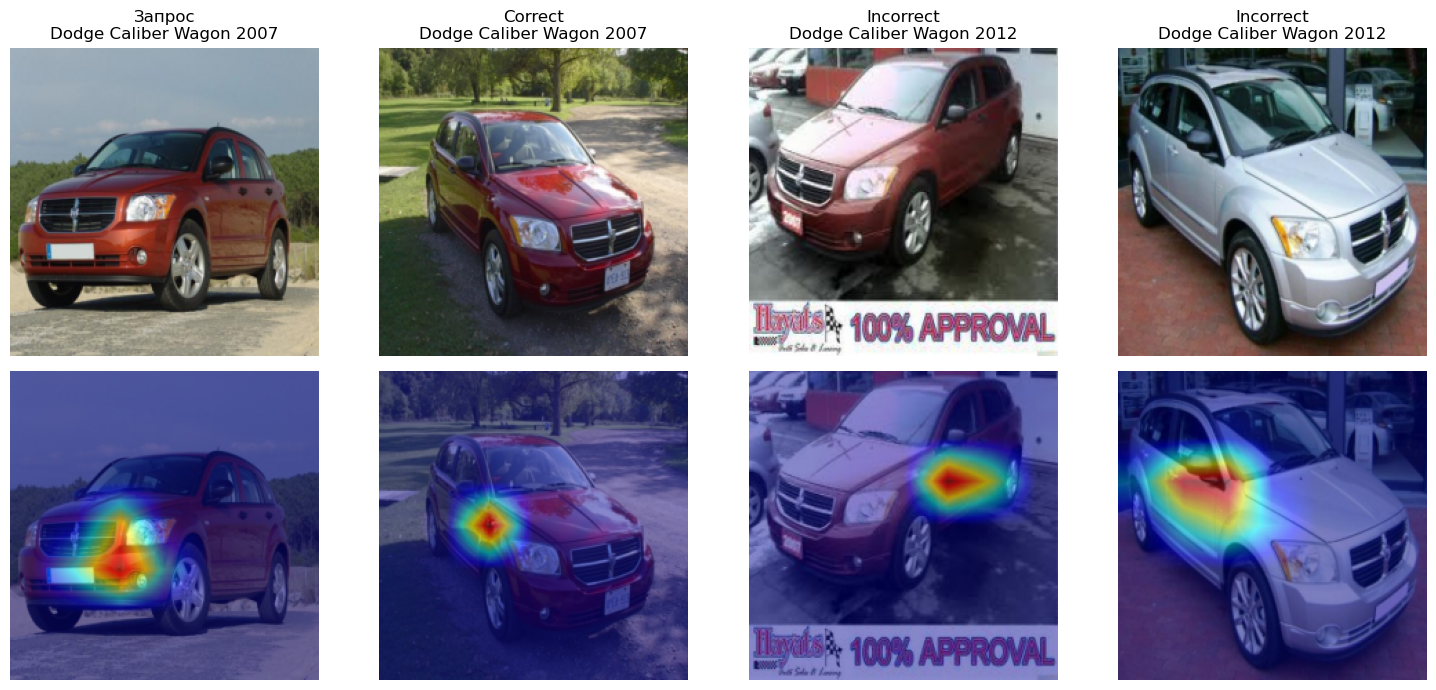

In [99]:
random_idx = random.randint(0, len(val_dataset) - 1)
find_and_show_similar_with_gradcam(pl_model, val_dataset, random_idx, k=3)

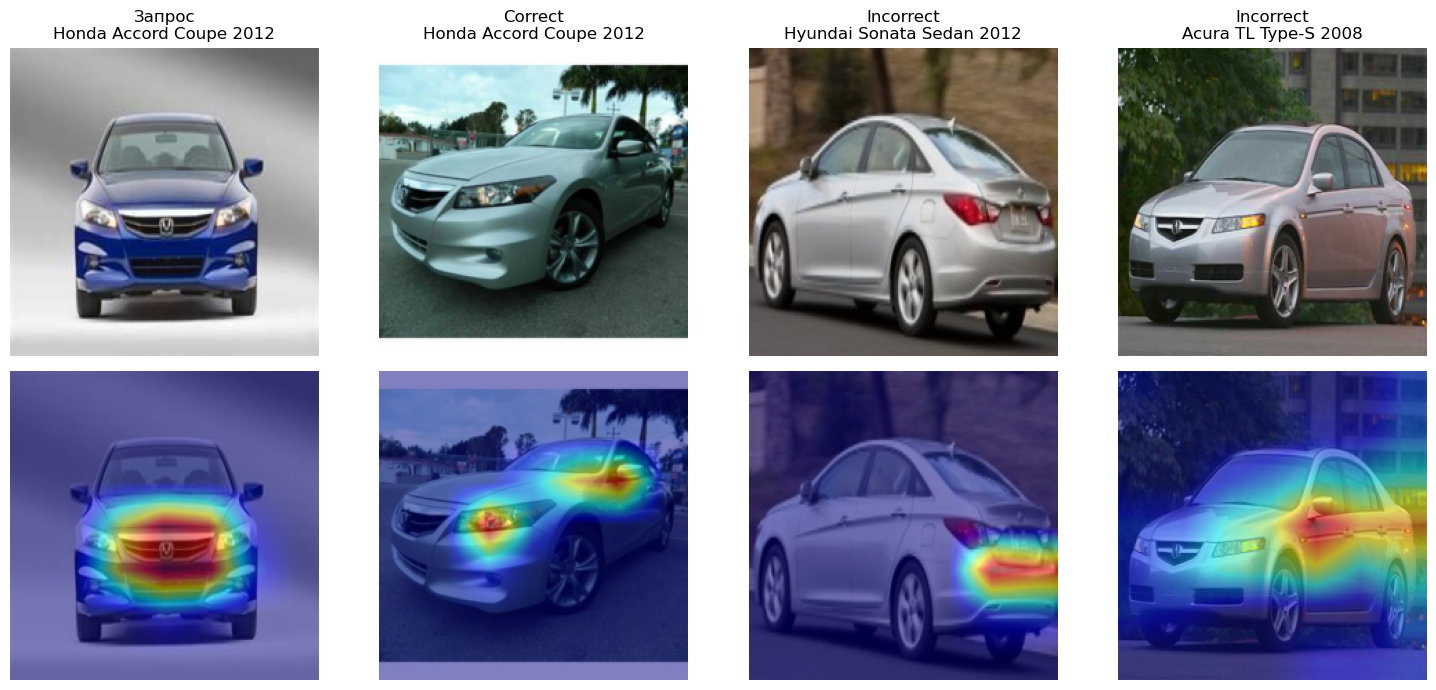

In [103]:
random_idx = random.randint(0, len(val_dataset) - 1)
find_and_show_similar_with_gradcam(pl_model, val_dataset, random_idx, k=3)

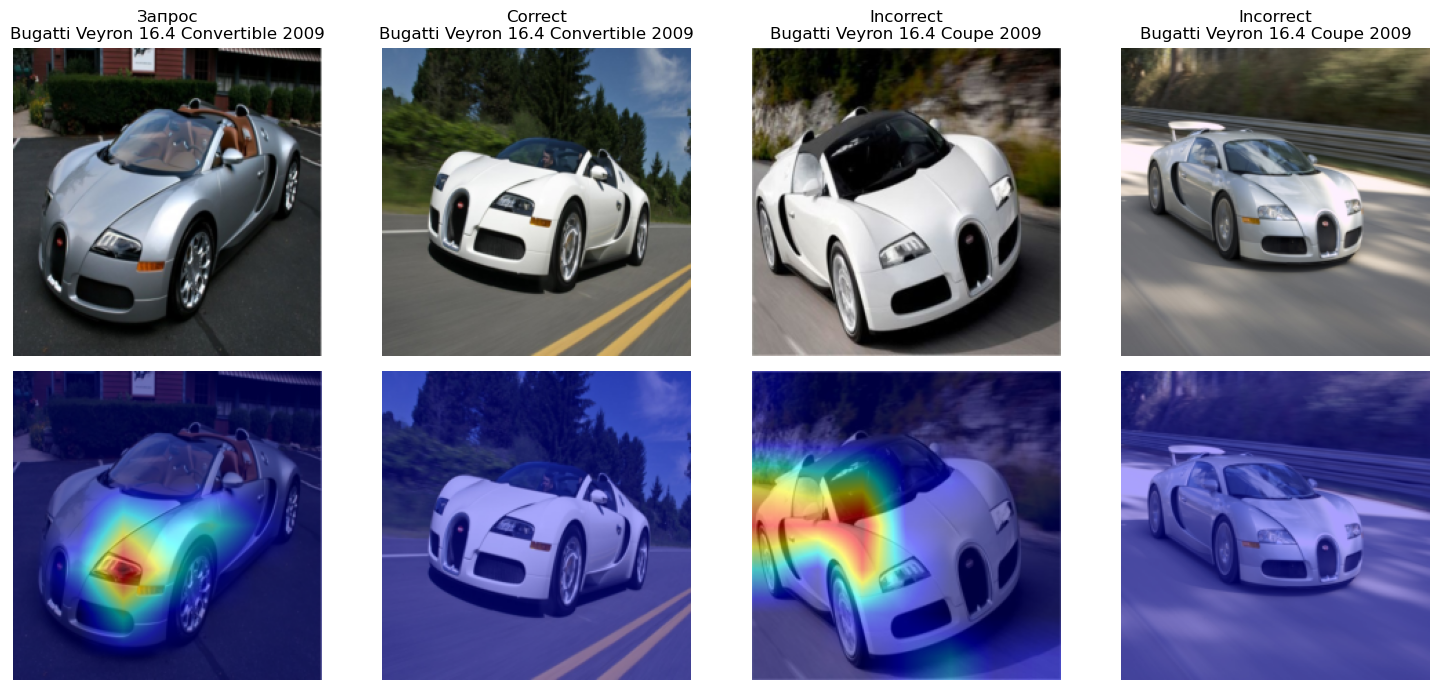

In [104]:
random_idx = random.randint(0, len(val_dataset) - 1)
find_and_show_similar_with_gradcam(pl_model, val_dataset, random_idx, k=3)